# 01. Developer Demographics Profile

This notebook explores the demographics of Stack Overflow Survey respondents from 2021 to 2025. We analyze:
1. Geographic distribution (Top countries)
2. Age demographics
3. Gender diversity
4. Overall and professional coding experience
5. Most common developer roles

In [9]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for visuals
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

# Resolve path to sql_connector relative to this notebook
current_dir = os.path.abspath('')
project_root = os.path.dirname(current_dir)
silver_utils_dir = os.path.join(project_root, 'Data Warehouse', 'Silver Layer', 'utils')
sys.path.append(silver_utils_dir)

# Ensure the images output directory exists
images_dir = os.path.join(current_dir, 'images')
os.makedirs(images_dir, exist_ok=True)

from sql_connector import SQLConnector

db = SQLConnector("Stack_Overflow_Survey")
db.connect()

Successfully Connected to Stack_Overflow_Survey


### 1. Geographic Distribution (Top 10 Countries)

Let's see where the survey respondents are located.

c:\Users\Ayush\Git Repo\Stack-Over-Flow-Survey-Data-Engineering-Project\Data Warehouse\Silver Layer\utils\sql_connector.py:46: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, self.conn)


Query executed successfully


C:\Users\Ayush\AppData\Local\Temp\ipykernel_11288\3069345137.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10, x='Count', y='Country', palette='viridis')


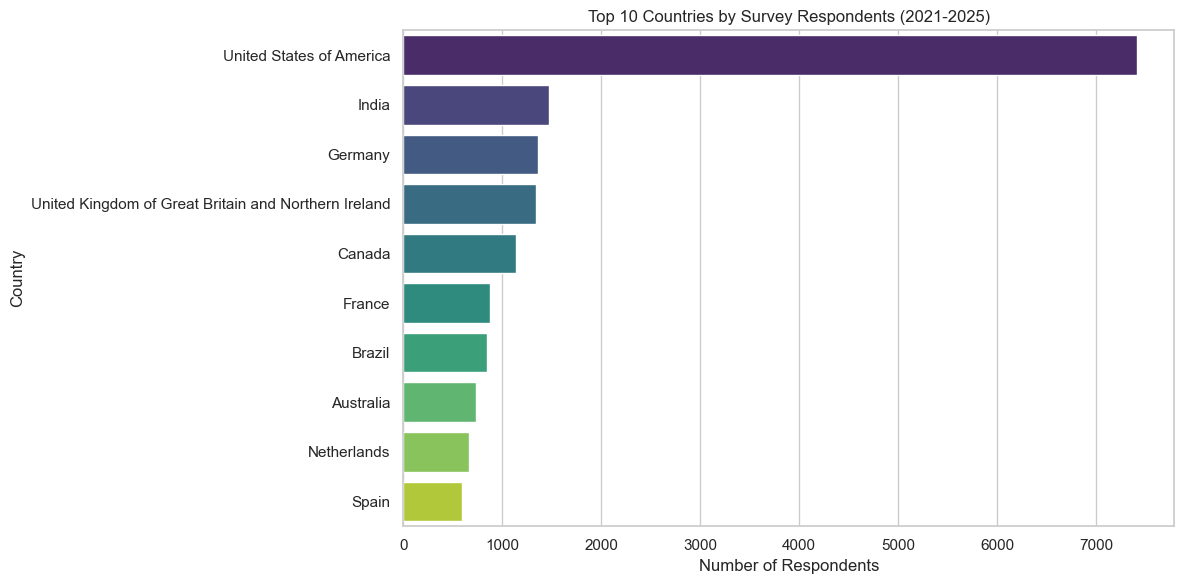

In [2]:
country_query = """
SELECT Country, COUNT(*) as Count
FROM Snowflake.Dim_Demographics
WHERE Country IS NOT NULL AND Country <> 'Unknown' AND Country <> ''
GROUP BY Country
ORDER BY Count DESC;
"""
df_country = db.read_query(country_query)

if df_country is not None and not df_country.empty:
    plt.figure(figsize=(12, 6))
    top_10 = df_country.head(10)
    sns.barplot(data=top_10, x='Count', y='Country', palette='viridis')
    plt.title('Top 10 Countries by Survey Respondents (2021-2025)')
    plt.xlabel('Number of Respondents')
    plt.ylabel('Country')
    plt.tight_layout()
    plt.savefig(os.path.join(images_dir, '01_top_countries.png'), dpi=300)
    plt.show()
else:
    print("No data retrieved or failed query.")

### 2. Age Demographics

Let's analyze the age distribution of developers over time.

c:\Users\Ayush\Git Repo\Stack-Over-Flow-Survey-Data-Engineering-Project\Data Warehouse\Silver Layer\utils\sql_connector.py:46: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, self.conn)


Query executed successfully


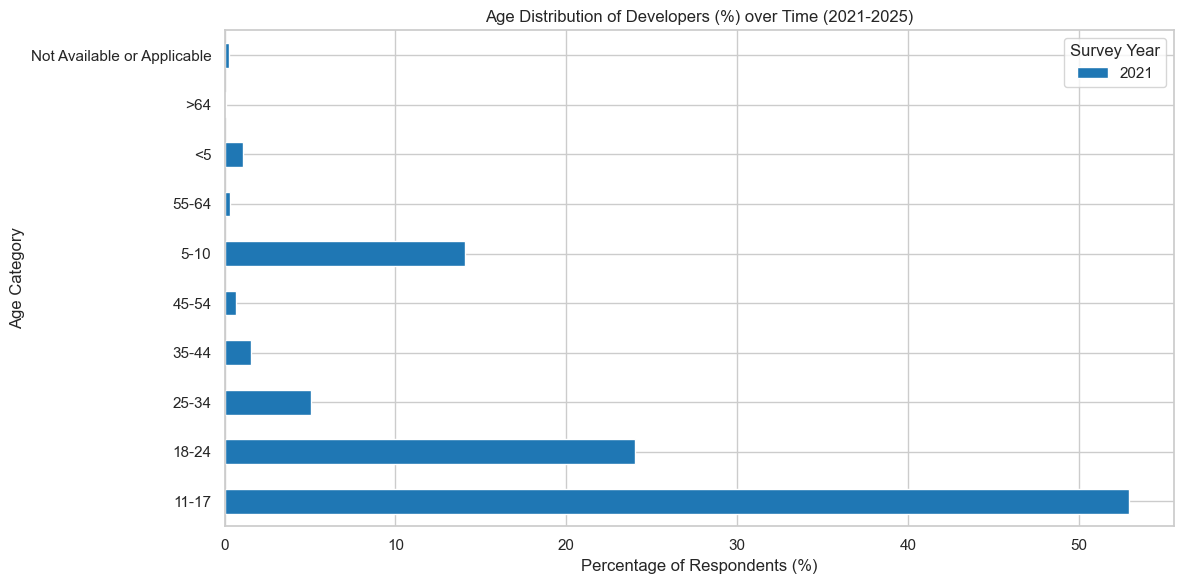

In [3]:
age_query = """
SELECT YEAR(f.SurveyYear) AS Year, d.AgeCode, COUNT(DISTINCT f.ResponseKey) AS Count
FROM Snowflake.Fact_Survey_Core f
JOIN Snowflake.Dim_Demographics d ON f.Dim_DemographicsID = d.Dim_DemographicsID
WHERE d.AgeCode IS NOT NULL 
  AND d.AgeCode NOT IN ('Under 18 years old', 'Prefer not to say', 'Unknown')
GROUP BY YEAR(f.SurveyYear), d.AgeCode;
"""
df_age = db.read_query(age_query)

if df_age is not None and not df_age.empty:
    df_age_pivot = df_age.pivot(index='AgeCode', columns='Year', values='Count').fillna(0)
    # Normalize to show percentage
    df_age_pct = df_age_pivot.div(df_age_pivot.sum(axis=0), axis=1) * 100
    
    df_age_pct.plot(kind='barh', figsize=(12, 6), colormap='tab20')
    plt.title('Age Distribution of Developers (%) over Time (2021-2025)')
    plt.xlabel('Percentage of Respondents (%)')
    plt.ylabel('Age Category')
    plt.legend(title='Survey Year')
    plt.tight_layout()
    plt.savefig(os.path.join(images_dir, '01_age_distribution.png'), dpi=300)
    plt.show()
else:
    print("No age data available.")

### 3. Gender Diversity

Let's see gender representation and how it evolves.

c:\Users\Ayush\Git Repo\Stack-Over-Flow-Survey-Data-Engineering-Project\Data Warehouse\Silver Layer\utils\sql_connector.py:46: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, self.conn)


Query executed successfully


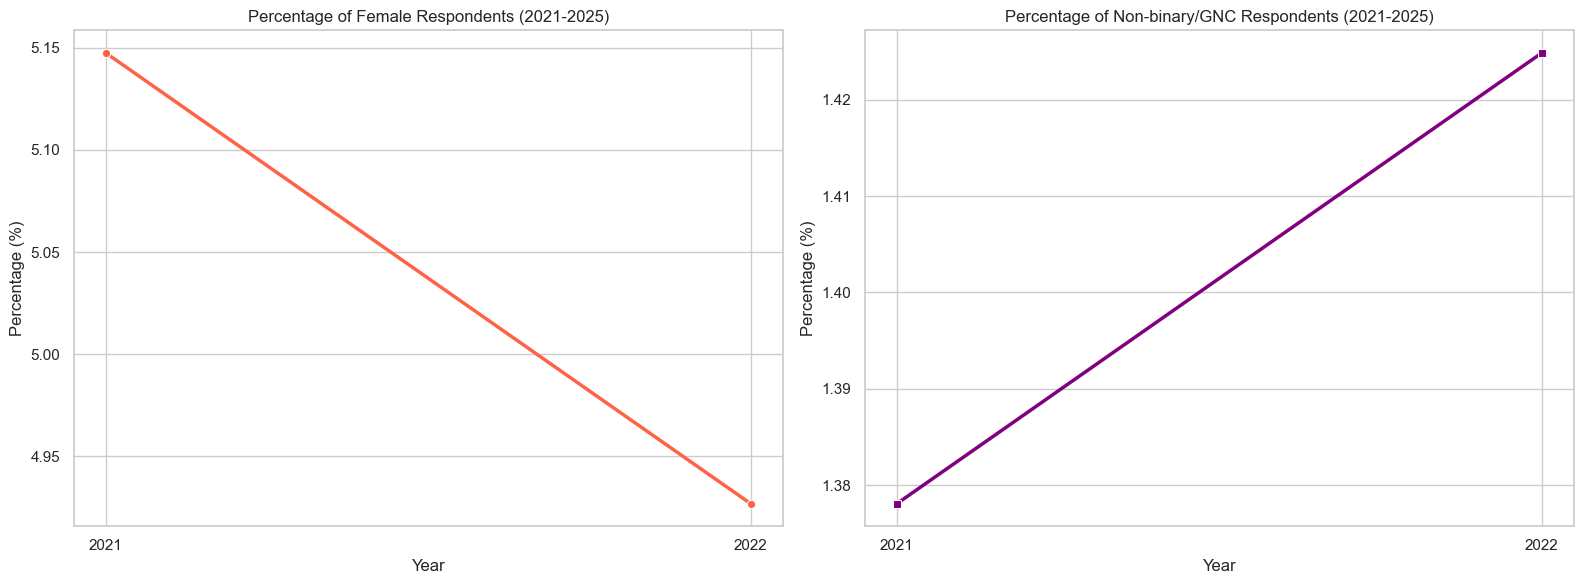

In [10]:
gender_query = """
SELECT YEAR(f.SurveyYear) AS Year, d.Gender_Clean, COUNT(DISTINCT f.ResponseKey) AS Count
FROM Snowflake.Fact_Survey_Core f
JOIN Snowflake.Dim_Demographics d ON f.Dim_DemographicsID = d.Dim_DemographicsID
WHERE d.Gender_Clean IS NOT NULL AND d.Gender_Clean IN ('Man', 'Woman', 'Non-binary / GNC')
GROUP BY YEAR(f.SurveyYear), d.Gender_Clean;
"""
df_gender = db.read_query(gender_query)

if df_gender is not None and not df_gender.empty:
    df_gender_pivot = df_gender.pivot(index='Year', columns='Gender_Clean', values='Count').fillna(0)
    df_gender_pct = df_gender_pivot.div(df_gender_pivot.sum(axis=1), axis=0) * 100
    
    # We'll plot Women and Non-binary on separate charts to see subtle trends clearly due to scale difference
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    sns.lineplot(data=df_gender_pct, x=df_gender_pct.index, y='Woman', marker='o', ax=axes[0], color='tomato', linewidth=2.5)
    axes[0].set_title('Percentage of Female Respondents (2021-2025)')
    axes[0].set_ylabel('Percentage (%)')
    axes[0].set_xlabel('Year')
    axes[0].set_xticks([2021, 2022])
    
    sns.lineplot(data=df_gender_pct, x=df_gender_pct.index, y='Non-binary / GNC', marker='s', ax=axes[1], color='purple', linewidth=2.5)
    axes[1].set_title('Percentage of Non-binary/GNC Respondents (2021-2025)')
    axes[1].set_ylabel('Percentage (%)')
    axes[1].set_xlabel('Year')
    axes[1].set_xticks([2021, 2022])
    
    plt.tight_layout()
    plt.savefig(os.path.join(images_dir, '01_gender_trends.png'), dpi=300)
    plt.show()
else:
    print("No gender data available.")

### 4. Experience Profiles

Let's check the relationship between years of coding overall vs. professional coding experience.

c:\Users\Ayush\Git Repo\Stack-Over-Flow-Survey-Data-Engineering-Project\Data Warehouse\Silver Layer\utils\sql_connector.py:46: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, self.conn)


Query executed successfully


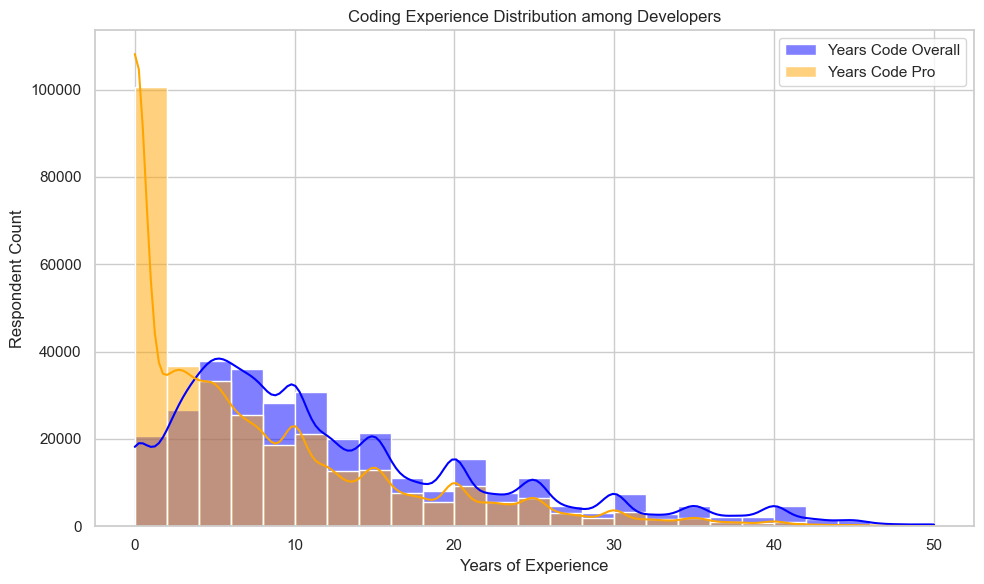

In [5]:
exp_query = """
SELECT YearsCode, YearsCodePro 
FROM Snowflake.Fact_Survey_Core 
WHERE YearsCode IS NOT NULL AND YearsCodePro IS NOT NULL 
  AND YearsCode <= 50 AND YearsCodePro <= 50;
"""
df_exp = db.read_query(exp_query)

if df_exp is not None and not df_exp.empty:
    plt.figure(figsize=(10, 6))
    sns.histplot(df_exp, x='YearsCode', kde=True, color='blue', label='Years Code Overall', alpha=0.5, bins=25)
    sns.histplot(df_exp, x='YearsCodePro', kde=True, color='orange', label='Years Code Pro', alpha=0.5, bins=25)
    plt.title('Coding Experience Distribution among Developers')
    plt.xlabel('Years of Experience')
    plt.ylabel('Respondent Count')
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(images_dir, '01_experience_distribution.png'), dpi=300)
    plt.show()
else:
    print("No experience data available.")

### 5. Developer Roles / Jobs

Let's see what roles are the most common in 2025.

c:\Users\Ayush\Git Repo\Stack-Over-Flow-Survey-Data-Engineering-Project\Data Warehouse\Silver Layer\utils\sql_connector.py:46: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, self.conn)


Query executed successfully


C:\Users\Ayush\AppData\Local\Temp\ipykernel_11288\2977708009.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_roles_2025, x='Count', y='DevType', palette='magma')


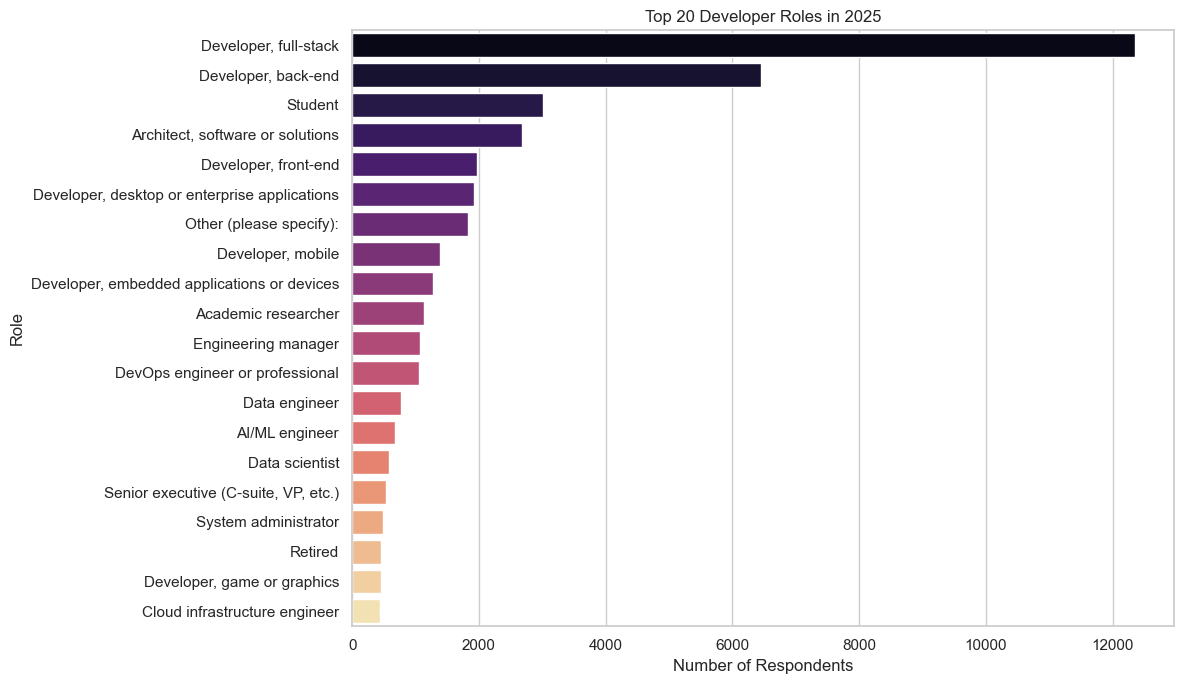

In [6]:
roles_query = """
SELECT YEAR(f.SurveyYear) AS Year, b.DevType_Clean AS DevType, COUNT(DISTINCT f.ResponseKey) AS Count
FROM Snowflake.Fact_Survey_Core f
JOIN Snowflake.Bridge_DevType_Clean b ON f.ResponseKey = b.ResponseKey
WHERE b.DevType_Clean IS NOT NULL AND b.DevType_Clean <> 'Unknown'
GROUP BY YEAR(f.SurveyYear), b.DevType_Clean;
"""
df_roles = db.read_query(roles_query)

if df_roles is not None and not df_roles.empty:
    df_roles_2025 = df_roles[df_roles['Year'] == 2025].sort_values(by='Count', ascending=False).head(20)
    plt.figure(figsize=(12, 7))
    sns.barplot(data=df_roles_2025, x='Count', y='DevType', palette='magma')
    plt.title('Top 20 Developer Roles in 2025')
    plt.xlabel('Number of Respondents')
    plt.ylabel('Role')
    plt.tight_layout()
    plt.savefig(os.path.join(images_dir, '01_dev_roles_2025.png'), dpi=300)
    plt.show()
else:
    print("No roles data available.")

In [7]:
db.close()

Connection closed.
